# PX4 Phase 1 Closed-Loop PINN-MPC v5 Tracking-Error Recovery

This notebook fixes the v18 tracking-error PINN checkpoint and tests recovery-oriented MPC.

The experiment is not a nominal maneuver test. The initial state is deliberately displaced from the hover setpoint, as if an external disturbance moved the vehicle. MPC then evaluates candidate setpoint/correction commands through the PINN and chooses the lowest-cost recovery command.

Workflow:

1. Load v18 tracking-error checkpoint.
2. Estimate learned hover equilibrium from v9 recovery dataset.
3. Confirm fixed-action hover equilibrium is stable.
4. Run recovery cases: north/east/alt/yaw/mixed initial offsets.
5. Report tracking-error recovery metrics and attitude safety.


In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as exc:
    print('Drive mount skipped:', type(exc).__name__, exc)


Mounted at /content/drive


In [2]:
import glob
import json
import math
import os
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('torch:', torch.__version__)


device: cuda
torch: 2.10.0+cu128


In [3]:
NOTEBOOK_REVISION = 'v14_attitude_projected_planning'
MANUAL_CHECKPOINT_PATH = ''
MANUAL_DATASET_DIR = ''
CHECKPOINT_GLOBS = [
    '/content/drive/MyDrive/Colab Result/PINN_MPC/px4_phase1_tracking_error_training_v18/**/px4_tracking_error_dynamics_pinn_v18.pt',
    '/content/drive/MyDrive/**/px4_tracking_error_dynamics_pinn_v18.pt',
    '/content/**/px4_tracking_error_dynamics_pinn_v18.pt',
]
DATASET_GLOBS = [
    '/content/drive/MyDrive/**/px4_phase1_recovery_tracking_error_dataset_v9_*',
    '/content/drive/MyDrive/**/processed/px4_phase1_recovery_tracking_error_dataset_v9_*',
    '/content/**/px4_phase1_recovery_tracking_error_dataset_v9_*',
]

RUN_MODE = 'fast_debug'  # fast_debug or full
DT = 0.05

if RUN_MODE == 'fast_debug':
    MPC_HORIZON = 35
    MPC_SAMPLES = 96
    MPC_ELITES = 12
    MPC_ITERS = 2
    CONTROL_INTERVAL_STEPS = 5
else:
    MPC_HORIZON = 80
    MPC_SAMPLES = 320
    MPC_ELITES = 32
    MPC_ITERS = 3
    CONTROL_INTERVAL_STEPS = 4

POS_LIMIT_M = 2.5
TARGET_ALT_M = 25.0
ALT_MIN_M = 22.0
ALT_MAX_M = 28.0
VEL_LIMIT_M_S = 0.30
VD_LIMIT_M_S = 0.20
YAW_OFFSET_LIMIT_DEG = 8.0

RUN_MPC_AFTER_DIAGNOSTIC = True
RECOVERY_SIM_TIME_S = 6.0 if RUN_MODE == 'fast_debug' else 12.0

RECOVERY_CASES_FULL = [
    {'name': 'D00_hover_equilibrium', 'dn': 0.0, 'de': 0.0, 'dalt': 0.0, 'dyaw': 0.0},
    {'name': 'D01_north_plus1m', 'dn': 1.0, 'de': 0.0, 'dalt': 0.0, 'dyaw': 0.0},
    {'name': 'D02_east_plus1m', 'dn': 0.0, 'de': 1.0, 'dalt': 0.0, 'dyaw': 0.0},
    {'name': 'D03_alt_low_1m', 'dn': 0.0, 'de': 0.0, 'dalt': -1.0, 'dyaw': 0.0},
    {'name': 'D04_yaw_plus8deg', 'dn': 0.0, 'de': 0.0, 'dalt': 0.0, 'dyaw': 8.0},
    {'name': 'D05_mixed_offset', 'dn': 0.8, 'de': -0.8, 'dalt': -0.6, 'dyaw': -6.0},
]
RECOVERY_CASES_FAST = RECOVERY_CASES_FULL[:2]
RECOVERY_CASES = RECOVERY_CASES_FAST if RUN_MODE == 'fast_debug' else RECOVERY_CASES_FULL

COST = dict(
    pos=48.0,
    alt=42.0,
    vel=24.0,
    yaw=10.0,
    terminal_pos=95.0,
    terminal_alt=120.0,
    terminal_yaw=36.0,
    terminal_vel=70.0,
    terminal_attitude=44.0,
    attitude=4.0,
    roll_attitude=18.0,
    pitch_attitude=7.0,
    rate=1.0,
    roll_rate=3.0,
    safety=2600.0,
    effort_pos=0.045,
    effort_vel=0.38,
    effort_yaw=0.18,
    smooth=1.20,
    action_delta=1.80,
)

# v8 deliberately narrows the search. The goal is stable recovery, not aggressive motion.
NOISE = dict(pos=0.08, alt=0.040, vel=0.018, vd=0.012, yaw=0.20)
STABILITY_SOFT_ATT_DEG = 2.5
STABILITY_HARD_ATT_DEG = 12.0
STABILITY_MAX_SPEED_M_S = 2.0
STABILITY_MAX_VERTICAL_SPEED_M_S = 0.9
NOOP_GUARD_MARGIN = 1.10
ACTIVE_ERROR_THRESHOLD_M = 0.20
# v12 uses target-position + velocity guidance instead of position overshoot.
# The previous guided candidate was often rejected because it placed the position
# setpoint behind the target; here we keep position at the target and command
# recovery primarily through velocity setpoints.
RECOVERY_REF_POS_GAIN = 0.0
RECOVERY_REF_VEL_GAIN = 0.24
RECOVERY_REF_ALT_GAIN = 0.0
RECOVERY_REF_VD_GAIN = 0.26
GUIDED_FORCE_ACTIVE = True
FORCE_GUIDED_MAX_ATT_DEG = 3.5
FORCE_GUIDED_MAX_SPEED_M_S = 0.55
FORCE_GUIDED_MAX_ALT_ERR_M = 1.8
GUIDED_RAMP_STEPS = 12

# v14 separates the raw PINN from the planning surrogate. The raw v18 model is
# roll-sensitive in recursive lateral rollout, so MPC uses a projected planning
# model that damps attitude/rate artifacts back toward the multicopter hover
# manifold while preserving position, velocity, altitude, and yaw dynamics.
USE_ATTITUDE_PROJECTED_PLANNING = True
ATTITUDE_PROJECTION_BLEND = 0.22
ATTITUDE_PROJECTION_CLIP_DEG = 3.0
RATE_PROJECTION_BLEND = 0.18
RATE_PROJECTION_CLIP_RAD_S = 0.18


In [4]:
def find_checkpoint():
    if MANUAL_CHECKPOINT_PATH:
        p = Path(MANUAL_CHECKPOINT_PATH)
        if p.exists():
            return p
        raise FileNotFoundError(f'MANUAL_CHECKPOINT_PATH not found: {p}')
    matches = []
    for pat in CHECKPOINT_GLOBS:
        matches.extend(Path(x) for x in glob.glob(pat, recursive=True))
    matches = sorted(set(p for p in matches if p.exists()))
    if not matches:
        raise FileNotFoundError('No v18 tracking-error PINN checkpoint found. Run the v18 training notebook first or set MANUAL_CHECKPOINT_PATH.')
    return matches[-1]

CKPT_PATH = find_checkpoint()
print('CKPT_PATH:', CKPT_PATH)
ckpt = torch.load(CKPT_PATH, map_location='cpu', weights_only=False)
print('revision:', ckpt.get('revision'))
print('dataset:', ckpt.get('dataset_dir'))
STATE_COLS = ckpt['state_cols']
ACTION_COLS = ckpt['action_cols']
TARGET_COLS = ckpt['target_cols']
FEATURE_COLS = ckpt['feature_cols']
ERROR_COLS = ckpt.get('error_cols', [])
print('state:', STATE_COLS)
print('action:', ACTION_COLS)
print('error:', ERROR_COLS)
print('feature dim:', len(FEATURE_COLS))

required_state = {'local_north_m', 'local_east_m', 'relative_altitude_m', 'yaw_deg'}
missing_state = sorted(required_state - set(STATE_COLS))
if missing_state:
    raise ValueError(f'This v5 MPC requires a position-state checkpoint. Missing state columns: {missing_state}')
required_features = {'e_ref_north_m', 'e_ref_east_m', 'e_ref_alt_m', 'e_ref_yaw_deg'}
missing_features = sorted(required_features - set(FEATURE_COLS))
if missing_features:
    raise ValueError(f'This v5 MPC requires the v18 tracking-error checkpoint. Missing feature columns: {missing_features}')


CKPT_PATH: /content/drive/MyDrive/Colab Result/PINN_MPC/px4_phase1_tracking_error_training_v18/20260510_021955/px4_tracking_error_dynamics_pinn_v18.pt
revision: v18_tracking_error
dataset: /content/drive/MyDrive/px4_datasets/processed/px4_phase1_recovery_tracking_error_dataset_v9_20260510_111046
state: ['local_north_m', 'local_east_m', 'relative_altitude_m', 'vel_north_m_s', 'vel_east_m_s', 'vel_down_m_s', 'roll_deg', 'pitch_deg', 'yaw_deg', 'roll_rate_rad_s', 'pitch_rate_rad_s', 'yaw_rate_rad_s']
action: ['ref_north_m', 'ref_east_m', 'ref_down_m', 'ref_north_m_s', 'ref_east_m_s', 'ref_down_m_s', 'ref_yaw_deg', 'ref_yaw_offset_deg']
error: ['ref_north_m', 'ref_east_m', 'ref_alt_m', 'ref_yaw_deg', 'ref_vn_m_s', 'ref_ve_m_s', 'ref_vd_m_s']
feature dim: 47


In [5]:
class ResidualMLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=256, depth=4, dropout=0.03):
        super().__init__()
        layers = []
        d = in_dim
        for _ in range(depth):
            layers += [nn.Linear(d, hidden), nn.LayerNorm(hidden), nn.SiLU(), nn.Dropout(dropout)]
            d = hidden
        layers.append(nn.Linear(d, out_dim))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

class Scaler:
    def __init__(self, payload):
        self.mean = torch.tensor(payload['mean'], dtype=torch.float32)
        self.std = torch.tensor(payload['std'], dtype=torch.float32).clamp_min(1e-8)
    def encode(self, x):
        return (torch.as_tensor(x, dtype=torch.float32) - self.mean) / self.std
    def decode(self, z):
        return z * self.std.to(z.device) + self.mean.to(z.device)

model_cfg = ckpt.get('model_config', {})
model = ResidualMLP(
    len(FEATURE_COLS), len(TARGET_COLS),
    hidden=int(model_cfg.get('hidden', 256)),
    depth=int(model_cfg.get('depth', 4)),
    dropout=float(model_cfg.get('dropout', 0.0)),
).to(device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
x_scaler = Scaler(ckpt['x_scaler'])
y_scaler = Scaler(ckpt['y_scaler'])
state_index = {c: i for i, c in enumerate(STATE_COLS)}
target_index = {c: i for i, c in enumerate(TARGET_COLS)}
feature_index = {c: i for i, c in enumerate(FEATURE_COLS)}


In [6]:
def wrap_deg_np(x):
    return ((x + 180.0) % 360.0) - 180.0

def tracking_error_feature(name, states, actions):
    if name == 'e_ref_north_m':
        return actions[:, ACTION_COLS.index('ref_north_m')] - states[:, state_index['local_north_m']]
    if name == 'e_ref_east_m':
        return actions[:, ACTION_COLS.index('ref_east_m')] - states[:, state_index['local_east_m']]
    if name == 'e_ref_alt_m':
        return -actions[:, ACTION_COLS.index('ref_down_m')] - states[:, state_index['relative_altitude_m']]
    if name == 'e_ref_yaw_deg':
        return wrap_deg_np(actions[:, ACTION_COLS.index('ref_yaw_deg')] - states[:, state_index['yaw_deg']])
    if name == 'e_ref_vn_m_s':
        return actions[:, ACTION_COLS.index('ref_north_m_s')] - states[:, state_index['vel_north_m_s']]
    if name == 'e_ref_ve_m_s':
        return actions[:, ACTION_COLS.index('ref_east_m_s')] - states[:, state_index['vel_east_m_s']]
    if name == 'e_ref_vd_m_s':
        return actions[:, ACTION_COLS.index('ref_down_m_s')] - states[:, state_index['vel_down_m_s']]
    raise KeyError(f'Unsupported tracking-error feature: {name}')

def build_feature_matrix(states, actions, prev_actions, dt=DT):
    states = np.asarray(states, dtype=np.float32)
    actions = np.asarray(actions, dtype=np.float32)
    prev_actions = np.asarray(prev_actions, dtype=np.float32)
    if states.ndim == 1:
        states = states[None, :]
    if actions.ndim == 1:
        actions = actions[None, :]
    if prev_actions.ndim == 1:
        prev_actions = prev_actions[None, :]
    du = actions - prev_actions
    n = states.shape[0]
    cols = []
    for name in FEATURE_COLS:
        if name == 'dt_s':
            cols.append(np.full(n, dt, dtype=np.float32))
        elif name == 'x_yaw_sin':
            cols.append(np.sin(np.deg2rad(states[:, state_index['yaw_deg']])))
        elif name == 'x_yaw_cos':
            cols.append(np.cos(np.deg2rad(states[:, state_index['yaw_deg']])))
        elif name.startswith('x_'):
            col = name[2:]
            cols.append(states[:, state_index[col]])
        elif name.startswith('u_') and name.endswith('_sin'):
            col = name[2:-4]
            cols.append(np.sin(np.deg2rad(actions[:, ACTION_COLS.index(col)])))
        elif name.startswith('u_') and name.endswith('_cos'):
            col = name[2:-4]
            cols.append(np.cos(np.deg2rad(actions[:, ACTION_COLS.index(col)])))
        elif name.startswith('prev_u_') and name.endswith('_sin'):
            col = name[7:-4]
            cols.append(np.sin(np.deg2rad(prev_actions[:, ACTION_COLS.index(col)])))
        elif name.startswith('prev_u_') and name.endswith('_cos'):
            col = name[7:-4]
            cols.append(np.cos(np.deg2rad(prev_actions[:, ACTION_COLS.index(col)])))
        elif name.startswith('u_'):
            col = name[2:]
            cols.append(actions[:, ACTION_COLS.index(col)])
        elif name.startswith('prev_u_'):
            col = name[7:]
            cols.append(prev_actions[:, ACTION_COLS.index(col)])
        elif name.startswith('du_'):
            col = name[3:]
            vals = du[:, ACTION_COLS.index(col)]
            if col in ['ref_yaw_deg', 'ref_yaw_offset_deg']:
                vals = wrap_deg_np(vals)
            cols.append(vals)
        elif name.startswith('e_'):
            vals = tracking_error_feature(name, states, actions)
            cols.append(vals.astype(np.float32))
        else:
            raise KeyError(f'Unsupported feature name: {name}')
    return np.stack(cols, axis=1).astype(np.float32)

@torch.no_grad()
def predict_delta(states, actions, prev_actions, dt=DT):
    X = build_feature_matrix(states, actions, prev_actions, dt)
    Xz = x_scaler.encode(X).to(device)
    dz = model(Xz)
    dy = y_scaler.decode(dz).cpu().numpy()
    return dy

def step_model(states, actions, prev_actions, dt=DT):
    dx = predict_delta(states, actions, prev_actions, dt)
    next_states = np.asarray(states, dtype=np.float32).copy() + dx.astype(np.float32)
    next_states[:, state_index['yaw_deg']] = wrap_deg_np(next_states[:, state_index['yaw_deg']])
    return next_states


def project_hover_attitude_manifold(states):
    projected = np.asarray(states, dtype=np.float32).copy()
    attitude_cols = ['roll_deg', 'pitch_deg']
    rate_cols = ['roll_rate_rad_s', 'pitch_rate_rad_s']
    for col in attitude_cols:
        idx = state_index[col]
        projected[:, idx] = (1.0 - ATTITUDE_PROJECTION_BLEND) * projected[:, idx]
        projected[:, idx] = np.clip(projected[:, idx], -ATTITUDE_PROJECTION_CLIP_DEG, ATTITUDE_PROJECTION_CLIP_DEG)
    for col in rate_cols:
        idx = state_index[col]
        projected[:, idx] = (1.0 - RATE_PROJECTION_BLEND) * projected[:, idx]
        projected[:, idx] = np.clip(projected[:, idx], -RATE_PROJECTION_CLIP_RAD_S, RATE_PROJECTION_CLIP_RAD_S)
    return projected

def planning_step_model(states, actions, prev_actions, dt=DT):
    next_states = step_model(states, actions, prev_actions, dt)
    if USE_ATTITUDE_PROJECTED_PLANNING:
        next_states = project_hover_attitude_manifold(next_states)
    return next_states



In [7]:
def make_action(ref_n=0.0, ref_e=0.0, ref_alt=TARGET_ALT_M, ref_vn=0.0, ref_ve=0.0, ref_vd=0.0, yaw_base_deg=90.0, yaw_offset_deg=0.0):
    values = {
        'ref_north_m': ref_n,
        'ref_east_m': ref_e,
        'ref_down_m': -ref_alt,
        'ref_north_m_s': ref_vn,
        'ref_east_m_s': ref_ve,
        'ref_down_m_s': ref_vd,
        'ref_yaw_deg': wrap_deg_np(yaw_base_deg + yaw_offset_deg),
        'ref_yaw_offset_deg': yaw_offset_deg,
    }
    return np.asarray([values[c] for c in ACTION_COLS], dtype=np.float32)

def clip_actions(actions, yaw_base_deg=90.0):
    a = np.asarray(actions, dtype=np.float32).copy()
    def col(name): return ACTION_COLS.index(name)
    a[..., col('ref_north_m')] = np.clip(a[..., col('ref_north_m')], -POS_LIMIT_M, POS_LIMIT_M)
    a[..., col('ref_east_m')] = np.clip(a[..., col('ref_east_m')], -POS_LIMIT_M, POS_LIMIT_M)
    alt = -a[..., col('ref_down_m')]
    alt = np.clip(alt, ALT_MIN_M, ALT_MAX_M)
    a[..., col('ref_down_m')] = -alt
    a[..., col('ref_north_m_s')] = np.clip(a[..., col('ref_north_m_s')], -VEL_LIMIT_M_S, VEL_LIMIT_M_S)
    a[..., col('ref_east_m_s')] = np.clip(a[..., col('ref_east_m_s')], -VEL_LIMIT_M_S, VEL_LIMIT_M_S)
    a[..., col('ref_down_m_s')] = np.clip(a[..., col('ref_down_m_s')], -VD_LIMIT_M_S, VD_LIMIT_M_S)
    a[..., col('ref_yaw_offset_deg')] = np.clip(a[..., col('ref_yaw_offset_deg')], -YAW_OFFSET_LIMIT_DEG, YAW_OFFSET_LIMIT_DEG)
    a[..., col('ref_yaw_deg')] = wrap_deg_np(yaw_base_deg + a[..., col('ref_yaw_offset_deg')])
    return a

def target_at_time(t, scenario='recovery'):
    return dict(n=0.0, e=0.0, alt=TARGET_ALT_M, yaw_offset=0.0)

def nominal_action_sequence(t0, horizon=MPC_HORIZON, yaw_base_deg=90.0, scenario='recovery'):
    tgt = target_at_time(t0, scenario=scenario)
    action = make_action(tgt['n'], tgt['e'], tgt['alt'], 0.0, 0.0, 0.0, yaw_base_deg, tgt['yaw_offset'])
    return clip_actions(np.repeat(action[None, :], horizon, axis=0), yaw_base_deg=yaw_base_deg)

def guided_recovery_action(state, yaw_base_deg=90.0, scenario='recovery'):
    tgt = target_at_time(0.0, scenario=scenario)
    north = float(state[state_index['local_north_m']])
    east = float(state[state_index['local_east_m']])
    alt = float(state[state_index['relative_altitude_m']])
    yaw = float(state[state_index['yaw_deg']])
    e_n = float(tgt['n'] - north)
    e_e = float(tgt['e'] - east)
    e_alt = float(tgt['alt'] - alt)
    e_yaw = float(wrap_deg_np(yaw_base_deg + tgt['yaw_offset'] - yaw))
    # Position setpoint stays at the task target. Recovery authority comes from
    # velocity setpoints, which is closer to the closed-loop PX4 data manifold.
    ref_n = tgt['n'] + RECOVERY_REF_POS_GAIN * e_n
    ref_e = tgt['e'] + RECOVERY_REF_POS_GAIN * e_e
    ref_alt = tgt['alt'] + RECOVERY_REF_ALT_GAIN * e_alt
    ref_vn = RECOVERY_REF_VEL_GAIN * e_n
    ref_ve = RECOVERY_REF_VEL_GAIN * e_e
    # PX4 down velocity is positive downward; positive altitude error means climb.
    ref_vd = -RECOVERY_REF_VD_GAIN * e_alt
    return make_action(ref_n, ref_e, ref_alt, ref_vn, ref_ve, ref_vd, yaw_base_deg, np.clip(e_yaw, -YAW_OFFSET_LIMIT_DEG, YAW_OFFSET_LIMIT_DEG))

def guided_recovery_sequence(initial_state, horizon=MPC_HORIZON, yaw_base_deg=90.0, scenario='recovery'):
    action = guided_recovery_action(initial_state, yaw_base_deg=yaw_base_deg, scenario=scenario)
    hover = nominal_action_sequence(0.0, horizon, yaw_base_deg=yaw_base_deg, scenario=scenario)[0]
    seq = np.repeat(action[None, :], horizon, axis=0)
    # Roll-sensitive model: ramp lateral/vertical velocity authority in gradually.
    # Position/yaw setpoints stay at the target from the beginning.
    vel_cols = [
        ACTION_COLS.index('ref_north_m_s'),
        ACTION_COLS.index('ref_east_m_s'),
        ACTION_COLS.index('ref_down_m_s'),
    ]
    for k in range(horizon):
        ramp = min(1.0, (k + 1) / max(1, GUIDED_RAMP_STEPS))
        seq[k, vel_cols] = hover[vel_cols] + ramp * (action[vel_cols] - hover[vel_cols])
    return clip_actions(seq, yaw_base_deg=yaw_base_deg)

def active_tracking_error(initial_state, yaw_base_deg=90.0, scenario='recovery'):
    tgt = target_at_time(0.0, scenario=scenario)
    dn = float(initial_state[state_index['local_north_m']] - tgt['n'])
    de = float(initial_state[state_index['local_east_m']] - tgt['e'])
    dalt = float(initial_state[state_index['relative_altitude_m']] - tgt['alt'])
    dyaw = float(wrap_deg_np(initial_state[state_index['yaw_deg']] - (yaw_base_deg + tgt['yaw_offset'])))
    return max(float(np.hypot(dn, de)), abs(dalt), abs(dyaw) / 8.0)

def sample_action_sequences(base_seq, prev_action, samples=MPC_SAMPLES, std_scale=1.0, yaw_base_deg=90.0):
    horizon = base_seq.shape[0]
    seq = np.repeat(base_seq[None, :, :], samples, axis=0)
    noise = np.zeros_like(seq)
    specs = [
        ('ref_north_m', NOISE['pos']), ('ref_east_m', NOISE['pos']), ('ref_down_m', NOISE['alt']),
        ('ref_north_m_s', NOISE['vel']), ('ref_east_m_s', NOISE['vel']), ('ref_down_m_s', NOISE['vd']),
        ('ref_yaw_offset_deg', NOISE['yaw']),
    ]
    for name, sigma in specs:
        raw = np.random.normal(0.0, sigma * std_scale, size=(samples, horizon))
        smooth = np.zeros_like(raw)
        alpha = 0.84
        smooth[:, 0] = raw[:, 0]
        for k in range(1, horizon):
            smooth[:, k] = alpha * smooth[:, k - 1] + (1.0 - alpha) * raw[:, k]
        noise[..., ACTION_COLS.index(name)] = smooth
    seq = seq + noise
    seq[:, 0, :] = 0.85 * prev_action + 0.15 * seq[:, 0, :]
    seq[0] = base_seq
    return clip_actions(seq, yaw_base_deg=yaw_base_deg)


In [8]:
def find_dataset_dir():
    if MANUAL_DATASET_DIR:
        p = Path(MANUAL_DATASET_DIR)
        if p.exists():
            return p
        raise FileNotFoundError(f'MANUAL_DATASET_DIR not found: {p}')
    ckpt_dataset = ckpt.get('dataset_dir', '')
    if ckpt_dataset:
        p = Path(ckpt_dataset)
        if p.exists():
            return p
    matches = []
    for pat in DATASET_GLOBS:
        matches.extend(Path(x) for x in glob.glob(pat, recursive=True))
    matches = sorted(set(p for p in matches if (p / 'train.csv').exists()))
    if not matches:
        raise FileNotFoundError('No processed v9 tracking-error dataset found. Set MANUAL_DATASET_DIR or rebuild v9 dataset.')
    return matches[-1]

DATASET_DIR = find_dataset_dir()
print('DATASET_DIR:', DATASET_DIR)
train_df = pd.read_csv(DATASET_DIR / 'train.csv')
val_df = pd.read_csv(DATASET_DIR / 'val.csv')
test_df = pd.read_csv(DATASET_DIR / 'test.csv')
all_data_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
print('rows:', {k: len(v) for k, v in [('train', train_df), ('val', val_df), ('test', test_df), ('all', all_data_df)]})
if (DATASET_DIR / 'dataset_summary.csv').exists():
    display(pd.read_csv(DATASET_DIR / 'dataset_summary.csv'))


DATASET_DIR: /content/drive/MyDrive/px4_datasets/processed/px4_phase1_recovery_tracking_error_dataset_v9_20260510_111046
rows: {'train': 33000, 'val': 5633, 'test': 6699, 'all': 45332}


,split,scenario,samples
0,test,R00_nominal_hold_25m,800
1,test,R01_north_offset_plus1_recover,653
2,test,R02_north_offset_minus1_recover,734
3,test,R03_east_offset_plus1_recover,1216
4,test,R04_east_offset_minus1_recover,597
5,test,R05_altitude_low_recover,898
6,test,R06_altitude_high_recover,211
7,test,R07_yaw_plus10_recover,920
8,test,R08_yaw_minus10_recover,480
9,test,R09_mixed_offset_recover,190


In [9]:
def median_vector(df, cols):
    return np.asarray([pd.to_numeric(df[c], errors='coerce').median() for c in cols], dtype=np.float32)

def make_manual_hover_state(yaw_base_deg=90.0):
    state = np.zeros(len(STATE_COLS), dtype=np.float32)
    values = {
        'local_north_m': 0.0,
        'local_east_m': 0.0,
        'relative_altitude_m': TARGET_ALT_M,
        'vel_north_m_s': 0.0,
        'vel_east_m_s': 0.0,
        'vel_down_m_s': 0.0,
        'roll_deg': 0.0,
        'pitch_deg': 0.0,
        'yaw_deg': yaw_base_deg,
        'roll_rate_rad_s': 0.0,
        'pitch_rate_rad_s': 0.0,
        'yaw_rate_rad_s': 0.0,
    }
    for k, v in values.items():
        state[state_index[k]] = v
    return state

def make_hover_action_from_row(row, yaw_base_deg=90.0):
    return make_action(
        ref_n=float(row.get('u_ref_north_m', 0.0)),
        ref_e=float(row.get('u_ref_east_m', 0.0)),
        ref_alt=float(-row.get('u_ref_down_m', -25.0)),
        ref_vn=float(row.get('u_ref_north_m_s', 0.0)),
        ref_ve=float(row.get('u_ref_east_m_s', 0.0)),
        ref_vd=float(row.get('u_ref_down_m_s', 0.0)),
        yaw_base_deg=yaw_base_deg,
        yaw_offset_deg=float(row.get('u_ref_yaw_offset_deg', 0.0)),
    )

def estimate_hover_candidates():
    hover = all_data_df[all_data_df['scenario'].isin(['R00_nominal_hold_25m', 'C00_position_hold_25m'])].copy()
    if len(hover) == 0:
        raise ValueError('Nominal hover scenario not found in processed dataset.')
    # Prefer calm rows near the commanded hover point.
    speed = np.sqrt(hover['x_vel_north_m_s'] ** 2 + hover['x_vel_east_m_s'] ** 2)
    calm = hover[
        (hover['x_relative_altitude_m'].between(23.5, 26.5))
        & (hover['x_roll_deg'].abs() < 3.0)
        & (hover['x_pitch_deg'].abs() < 3.0)
        & (speed < 0.25)
    ].copy()
    if len(calm) < 50:
        calm = hover.copy()
    x_cols = [f'x_{c}' for c in STATE_COLS]
    u_cols = [f'u_{c}' for c in ACTION_COLS]
    med_state = median_vector(calm, x_cols)
    med_action = median_vector(calm, u_cols)
    target_aligned_state = med_state.copy()
    target_aligned_state[state_index['local_north_m']] = med_action[ACTION_COLS.index('ref_north_m')]
    target_aligned_state[state_index['local_east_m']] = med_action[ACTION_COLS.index('ref_east_m')]
    target_aligned_state[state_index['relative_altitude_m']] = -med_action[ACTION_COLS.index('ref_down_m')]
    target_aligned_state[state_index['vel_north_m_s']] = 0.0
    target_aligned_state[state_index['vel_east_m_s']] = 0.0
    target_aligned_state[state_index['vel_down_m_s']] = 0.0
    manual_state = make_manual_hover_state(float(med_state[state_index['yaw_deg']]))
    manual_action = make_action(0.0, 0.0, TARGET_ALT_M, yaw_base_deg=float(med_state[state_index['yaw_deg']]), yaw_offset_deg=0.0)
    return {
        'manual_zero': (manual_state, manual_action),
        'data_median': (med_state, med_action),
        'target_aligned': (target_aligned_state, med_action),
    }, calm

hover_candidates, hover_reference_df = estimate_hover_candidates()
print('hover reference rows:', len(hover_reference_df))
print('candidate state/action summary:')
rows = []
for name, (s, a) in hover_candidates.items():
    row = {'candidate': name}
    for c in ['local_north_m', 'local_east_m', 'relative_altitude_m', 'vel_north_m_s', 'vel_east_m_s', 'vel_down_m_s', 'roll_deg', 'pitch_deg', 'yaw_deg']:
        row[c] = float(s[state_index[c]])
    for c in ['ref_north_m', 'ref_east_m', 'ref_down_m', 'ref_north_m_s', 'ref_east_m_s', 'ref_down_m_s', 'ref_yaw_offset_deg']:
        row[c] = float(a[ACTION_COLS.index(c)])
    rows.append(row)
display(pd.DataFrame(rows))


hover reference rows: 3490
candidate state/action summary:


,candidate,local_north_m,local_east_m,relative_altitude_m,vel_north_m_s,vel_east_m_s,vel_down_m_s,roll_deg,pitch_deg,yaw_deg,ref_north_m,ref_east_m,ref_down_m,ref_north_m_s,ref_east_m_s,ref_down_m_s,ref_yaw_offset_deg
0,manual_zero,0.000000,0.000000,25.000,0.0,0.0,0.0,0.000000,0.000000,95.528397,0.0,0.0,-25.0,0.0,0.0,0.0,0.0
1,data_median,-0.034714,-0.001891,25.027,0.0,0.0,0.0,0.069956,-0.144892,95.528397,0.0,0.0,-25.0,0.0,0.0,0.0,0.0
2,target_aligned,0.000000,0.000000,25.000,0.0,0.0,0.0,0.069956,-0.144892,95.528397,0.0,0.0,-25.0,0.0,0.0,0.0,0.0


In [10]:
def fixed_action_rollout(init_state, action, seconds=10.0, label='fixed_hover'):
    state = np.asarray(init_state, dtype=np.float32).copy()
    action = np.asarray(action, dtype=np.float32).copy()
    prev_action = action.copy()
    rows = []
    steps = int(seconds / DT)
    for step in range(steps):
        t = step * DT
        next_state = step_model(state[None, :], action[None, :], prev_action[None, :], DT)[0]
        rows.append({
            'label': label,
            'time_s': t,
            'north_m': float(next_state[state_index['local_north_m']]),
            'east_m': float(next_state[state_index['local_east_m']]),
            'alt_m': float(next_state[state_index['relative_altitude_m']]),
            'vn_m_s': float(next_state[state_index['vel_north_m_s']]),
            've_m_s': float(next_state[state_index['vel_east_m_s']]),
            'vd_m_s': float(next_state[state_index['vel_down_m_s']]),
            'roll_deg': float(next_state[state_index['roll_deg']]),
            'pitch_deg': float(next_state[state_index['pitch_deg']]),
            'yaw_deg': float(next_state[state_index['yaw_deg']]),
            'roll_rate_rad_s': float(next_state[state_index['roll_rate_rad_s']]),
            'pitch_rate_rad_s': float(next_state[state_index['pitch_rate_rad_s']]),
            'yaw_rate_rad_s': float(next_state[state_index['yaw_rate_rad_s']]),
        })
        prev_action = action
        state = next_state
    return pd.DataFrame(rows)

def hover_rollout_metrics(log, init_state):
    speed = np.sqrt(log['vn_m_s'] ** 2 + log['ve_m_s'] ** 2)
    pos = np.sqrt((log['north_m'] - float(init_state[state_index['local_north_m']])) ** 2 + (log['east_m'] - float(init_state[state_index['local_east_m']])) ** 2)
    alt_err = log['alt_m'] - float(init_state[state_index['relative_altitude_m']])
    return {
        'label': str(log['label'].iloc[0]),
        'pos_drift_final_m': float(pos.iloc[-1]),
        'pos_drift_max_m': float(pos.max()),
        'alt_drift_final_m': float(alt_err.iloc[-1]),
        'alt_rmse_m': float(np.sqrt(np.mean(alt_err ** 2))),
        'speed_max_m_s': float(speed.max()),
        'max_abs_roll_deg': float(np.max(np.abs(log['roll_deg']))),
        'max_abs_pitch_deg': float(np.max(np.abs(log['pitch_deg']))),
        'yaw_drift_final_deg': float(wrap_deg_np(log['yaw_deg'].iloc[-1] - log['yaw_deg'].iloc[0])),
    }

hover_logs = []
hover_metric_rows = []
for name, (s, a) in hover_candidates.items():
    log = fixed_action_rollout(s, a, seconds=10.0, label=name)
    hover_logs.append(log)
    hover_metric_rows.append(hover_rollout_metrics(log, s))
hover_diagnostic_log = pd.concat(hover_logs, ignore_index=True)
hover_diagnostic_metrics = pd.DataFrame(hover_metric_rows)
hover_diagnostic_metrics['score'] = (
    hover_diagnostic_metrics['alt_rmse_m']
    + 0.8 * hover_diagnostic_metrics['pos_drift_final_m']
    + 0.5 * hover_diagnostic_metrics['speed_max_m_s']
    + 0.05 * hover_diagnostic_metrics['max_abs_roll_deg']
    + 0.05 * hover_diagnostic_metrics['max_abs_pitch_deg']
)
hover_diagnostic_metrics = hover_diagnostic_metrics.sort_values('score').reset_index(drop=True)
display(hover_diagnostic_metrics)
BEST_HOVER_LABEL = str(hover_diagnostic_metrics.iloc[0]['label'])
HOVER_STATE, HOVER_ACTION = hover_candidates[BEST_HOVER_LABEL]
print('BEST_HOVER_LABEL:', BEST_HOVER_LABEL)
print('HOVER_ACTION:', dict(zip(ACTION_COLS, [float(x) for x in HOVER_ACTION])))


,label,pos_drift_final_m,pos_drift_max_m,alt_drift_final_m,alt_rmse_m,speed_max_m_s,max_abs_roll_deg,max_abs_pitch_deg,yaw_drift_final_deg,score
0,data_median,0.025852,0.025852,0.028753,0.018190,0.003551,0.098996,0.246662,0.008362,0.057930
1,target_aligned,0.029652,0.029652,0.032200,0.023280,0.003367,0.134034,0.177381,0.002686,0.064256
2,manual_zero,0.026388,0.026388,0.032896,0.024408,0.006711,0.150277,0.295286,0.007507,0.071152


BEST_HOVER_LABEL: data_median
HOVER_ACTION: {'ref_north_m': 0.0, 'ref_east_m': 0.0, 'ref_down_m': -25.0, 'ref_north_m_s': 0.0, 'ref_east_m_s': 0.0, 'ref_down_m_s': 0.0, 'ref_yaw_deg': 95.51640319824219, 'ref_yaw_offset_deg': 0.0}


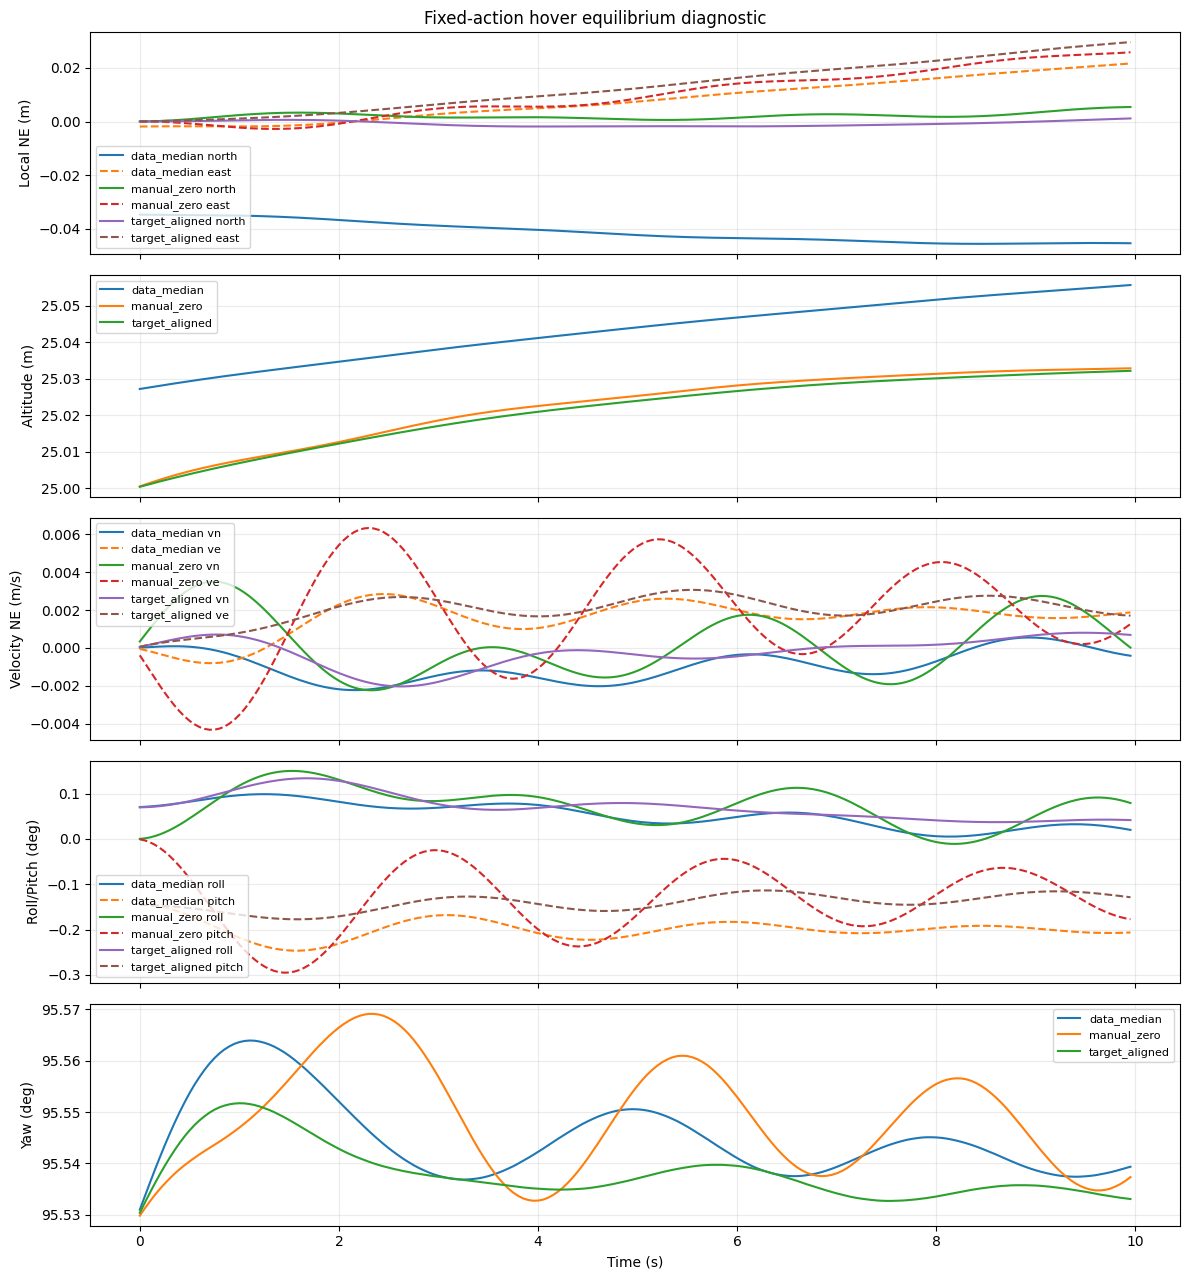

In [11]:
fig, axes = plt.subplots(5, 1, figsize=(12, 13), sharex=True)
for label, g in hover_diagnostic_log.groupby('label'):
    t = g['time_s']
    axes[0].plot(t, g['north_m'], label=f'{label} north')
    axes[0].plot(t, g['east_m'], ls='--', label=f'{label} east')
    axes[1].plot(t, g['alt_m'], label=label)
    axes[2].plot(t, g['vn_m_s'], label=f'{label} vn')
    axes[2].plot(t, g['ve_m_s'], ls='--', label=f'{label} ve')
    axes[3].plot(t, g['roll_deg'], label=f'{label} roll')
    axes[3].plot(t, g['pitch_deg'], ls='--', label=f'{label} pitch')
    axes[4].plot(t, g['yaw_deg'], label=label)
axes[0].set_ylabel('Local NE (m)')
axes[1].set_ylabel('Altitude (m)')
axes[2].set_ylabel('Velocity NE (m/s)')
axes[3].set_ylabel('Roll/Pitch (deg)')
axes[4].set_ylabel('Yaw (deg)')
axes[4].set_xlabel('Time (s)')
for ax in axes:
    ax.grid(True, alpha=0.25)
    ax.legend(loc='best', fontsize=8)
fig.suptitle('Fixed-action hover equilibrium diagnostic')
fig.tight_layout()
plt.show()


In [12]:
def trajectory_targets(times, scenario='recovery'):
    return [target_at_time(float(t), scenario=scenario) for t in times]

def running_cost(states, actions, prev_actions, targets, yaw_base_deg=90.0):
    north = states[:, state_index['local_north_m']]
    east = states[:, state_index['local_east_m']]
    alt = states[:, state_index['relative_altitude_m']]
    vn = states[:, state_index['vel_north_m_s']]
    ve = states[:, state_index['vel_east_m_s']]
    vd = states[:, state_index['vel_down_m_s']]
    yaw = states[:, state_index['yaw_deg']]
    roll = states[:, state_index['roll_deg']]
    pitch = states[:, state_index['pitch_deg']]
    p = states[:, state_index['roll_rate_rad_s']]
    q = states[:, state_index['pitch_rate_rad_s']]
    r = states[:, state_index['yaw_rate_rad_s']]

    tgt_n = np.asarray([x['n'] for x in targets], dtype=np.float32)
    tgt_e = np.asarray([x['e'] for x in targets], dtype=np.float32)
    tgt_alt = np.asarray([x['alt'] for x in targets], dtype=np.float32)
    tgt_yaw = wrap_deg_np(yaw_base_deg + np.asarray([x['yaw_offset'] for x in targets], dtype=np.float32))

    e_n = tgt_n - north
    e_e = tgt_e - east
    e_alt = tgt_alt - alt
    e_yaw = wrap_deg_np(tgt_yaw - yaw)
    ref_vel = actions[:, [ACTION_COLS.index('ref_north_m_s'), ACTION_COLS.index('ref_east_m_s'), ACTION_COLS.index('ref_down_m_s')]]

    pos_cost = COST['pos'] * (e_n ** 2 + e_e ** 2)
    alt_cost = COST['alt'] * (e_alt ** 2)
    vel_cost = COST['vel'] * (vn ** 2 + ve ** 2 + 0.7 * vd ** 2)
    yaw_cost = COST['yaw'] * (e_yaw / 8.0) ** 2
    # Roll is the sensitive axis in the current surrogate, so penalize it
    # separately instead of hiding it inside a symmetric attitude norm.
    attitude_cost = COST['roll_attitude'] * roll ** 2 + COST['pitch_attitude'] * pitch ** 2
    rate_cost = COST['rate'] * np.rad2deg(np.sqrt(q ** 2 + r ** 2)) ** 2
    rate_cost += COST['roll_rate'] * np.rad2deg(np.abs(p)) ** 2
    ref_north = actions[:, ACTION_COLS.index('ref_north_m')]
    ref_east = actions[:, ACTION_COLS.index('ref_east_m')]
    ref_alt = -actions[:, ACTION_COLS.index('ref_down_m')]
    effort = COST['effort_pos'] * (ref_north ** 2 + ref_east ** 2 + (ref_alt - TARGET_ALT_M) ** 2)
    effort += COST['effort_vel'] * np.sum(ref_vel ** 2, axis=1)
    effort += COST['effort_yaw'] * (actions[:, ACTION_COLS.index('ref_yaw_offset_deg')] / 8.0) ** 2
    smooth = COST['smooth'] * np.mean((actions - prev_actions) ** 2, axis=1)
    action_delta = COST['action_delta'] * np.mean((actions - prev_actions) ** 2, axis=1)

    safety = np.zeros_like(pos_cost)
    safety += COST['safety'] * np.maximum(np.abs(roll) - STABILITY_SOFT_ATT_DEG, 0.0) ** 2
    safety += COST['safety'] * np.maximum(np.abs(pitch) - STABILITY_SOFT_ATT_DEG, 0.0) ** 2
    safety += COST['safety'] * np.maximum(ALT_MIN_M - alt, 0.0) ** 2
    safety += COST['safety'] * np.maximum(alt - ALT_MAX_M, 0.0) ** 2
    safety += 700.0 * np.maximum(np.sqrt(vn ** 2 + ve ** 2) - 0.8, 0.0) ** 2
    safety += 700.0 * np.maximum(np.abs(vd) - 0.45, 0.0) ** 2
    return pos_cost + alt_cost + vel_cost + yaw_cost + attitude_cost + rate_cost + effort + smooth + action_delta + safety

def terminal_cost(states, target, yaw_base_deg=90.0):
    north = states[:, state_index['local_north_m']]
    east = states[:, state_index['local_east_m']]
    alt = states[:, state_index['relative_altitude_m']]
    yaw = states[:, state_index['yaw_deg']]
    vn = states[:, state_index['vel_north_m_s']]
    ve = states[:, state_index['vel_east_m_s']]
    vd = states[:, state_index['vel_down_m_s']]
    roll = states[:, state_index['roll_deg']]
    pitch = states[:, state_index['pitch_deg']]
    tgt_yaw = wrap_deg_np(yaw_base_deg + target['yaw_offset'])
    return (
        COST['terminal_pos'] * ((north - target['n']) ** 2 + (east - target['e']) ** 2)
        + COST['terminal_alt'] * (alt - target['alt']) ** 2
        + COST['terminal_yaw'] * (wrap_deg_np(yaw - tgt_yaw) / 8.0) ** 2
        + COST['terminal_vel'] * (vn ** 2 + ve ** 2 + 0.7 * vd ** 2)
        + COST['terminal_attitude'] * (2.5 * roll ** 2 + pitch ** 2)
    )


In [13]:

def rollout_sequence_summary(initial_state, prev_action, action_sequence, t0=0.0, yaw_base_deg=90.0, scenario='recovery'):
    state = np.asarray(initial_state, dtype=np.float32).copy()
    prev = np.asarray(prev_action, dtype=np.float32).copy()
    max_roll = abs(float(state[state_index['roll_deg']]))
    max_pitch = abs(float(state[state_index['pitch_deg']]))
    max_speed = float(np.hypot(state[state_index['vel_north_m_s']], state[state_index['vel_east_m_s']]))
    max_alt_err = abs(float(state[state_index['relative_altitude_m']] - TARGET_ALT_M))
    for k, action in enumerate(action_sequence):
        state = planning_step_model(state[None, :], action[None, :], prev[None, :], DT)[0].astype(np.float32).copy()
        prev = np.asarray(action, dtype=np.float32).copy()
        max_roll = max(max_roll, abs(float(state[state_index['roll_deg']])))
        max_pitch = max(max_pitch, abs(float(state[state_index['pitch_deg']])))
        max_speed = max(max_speed, float(np.hypot(state[state_index['vel_north_m_s']], state[state_index['vel_east_m_s']])))
        max_alt_err = max(max_alt_err, abs(float(state[state_index['relative_altitude_m']] - TARGET_ALT_M)))
    tgt = target_at_time(t0 + len(action_sequence) * DT, scenario=scenario)
    pos_err = float(np.hypot(state[state_index['local_north_m']] - tgt['n'], state[state_index['local_east_m']] - tgt['e']))
    alt_err = float(state[state_index['relative_altitude_m']] - tgt['alt'])
    yaw_err = float(wrap_deg_np(state[state_index['yaw_deg']] - (yaw_base_deg + tgt['yaw_offset'])))
    speed = float(np.hypot(state[state_index['vel_north_m_s']], state[state_index['vel_east_m_s']]))
    return {
        'final_pos_err_m': pos_err,
        'final_alt_err_m': alt_err,
        'final_yaw_err_deg': yaw_err,
        'final_speed_m_s': speed,
        'max_abs_roll_deg': max_roll,
        'max_abs_pitch_deg': max_pitch,
        'max_speed_m_s': max_speed,
        'max_alt_err_m': max_alt_err,
    }

def evaluate_sequences(initial_state, prev_action, action_sequences, t0=0.0, yaw_base_deg=90.0, scenario='recovery'):
    samples, horizon, _ = action_sequences.shape
    states = np.repeat(initial_state[None, :], samples, axis=0).astype(np.float32)
    prev = np.repeat(prev_action[None, :], samples, axis=0).astype(np.float32)
    costs = np.zeros(samples, dtype=np.float32)
    hard_fail = np.zeros(samples, dtype=bool)
    for k in range(horizon):
        actions = action_sequences[:, k, :]
        times = t0 + (k + 1) * DT
        targets = trajectory_targets(np.full(samples, times), scenario=scenario)
        states = planning_step_model(states, actions, prev, DT)
        costs += running_cost(states, actions, prev, targets, yaw_base_deg=yaw_base_deg)
        hard_fail |= np.abs(states[:, state_index['roll_deg']]) > STABILITY_HARD_ATT_DEG
        hard_fail |= np.abs(states[:, state_index['pitch_deg']]) > STABILITY_HARD_ATT_DEG
        hard_fail |= states[:, state_index['relative_altitude_m']] < 18.0
        hard_fail |= states[:, state_index['relative_altitude_m']] > 32.0
        hard_fail |= np.sqrt(states[:, state_index['vel_north_m_s']] ** 2 + states[:, state_index['vel_east_m_s']] ** 2) > STABILITY_MAX_SPEED_M_S
        hard_fail |= np.abs(states[:, state_index['vel_down_m_s']]) > STABILITY_MAX_VERTICAL_SPEED_M_S
        prev = actions
    costs += terminal_cost(states, target_at_time(t0 + horizon * DT, scenario=scenario), yaw_base_deg=yaw_base_deg)
    costs[hard_fail] += 1e8
    return costs

def mppi_plan(initial_state, prev_action, t0=0.0, yaw_base_deg=90.0, scenario='recovery', warm_start=None):
    nominal_seq = nominal_action_sequence(t0, MPC_HORIZON, yaw_base_deg=yaw_base_deg, scenario=scenario)
    guided_seq = guided_recovery_sequence(initial_state, MPC_HORIZON, yaw_base_deg=yaw_base_deg, scenario=scenario)
    nominal_cost = float(evaluate_sequences(
        initial_state, prev_action, nominal_seq[None, :, :],
        t0=t0, yaw_base_deg=yaw_base_deg, scenario=scenario,
    )[0])
    guided_cost = float(evaluate_sequences(
        initial_state, prev_action, guided_seq[None, :, :],
        t0=t0, yaw_base_deg=yaw_base_deg, scenario=scenario,
    )[0])
    active_error = active_tracking_error(initial_state, yaw_base_deg=yaw_base_deg, scenario=scenario)
    if guided_cost < nominal_cost:
        best_seq = guided_seq.copy()
        best_cost = guided_cost
        best_source = 'guided'
    else:
        best_seq = nominal_seq.copy()
        best_cost = nominal_cost
        best_source = 'nominal'
    if warm_start is not None and len(warm_start) == MPC_HORIZON:
        base_seq = 0.25 * warm_start + 0.35 * best_seq + 0.40 * guided_seq
    else:
        base_seq = best_seq
    std_scale = 1.0
    for _ in range(MPC_ITERS):
        seq = sample_action_sequences(base_seq, prev_action, MPC_SAMPLES, std_scale=std_scale, yaw_base_deg=yaw_base_deg)
        seq[0] = nominal_seq
        seq[1] = guided_seq
        seq[2] = best_seq
        costs = evaluate_sequences(initial_state, prev_action, seq, t0=t0, yaw_base_deg=yaw_base_deg, scenario=scenario)
        elite_idx = np.argsort(costs)[:MPC_ELITES]
        elite = seq[elite_idx]
        weights = np.exp(-(costs[elite_idx] - costs[elite_idx[0]]) / max(np.std(costs[elite_idx]), 1e-6))
        weights = weights / np.sum(weights)
        candidate_seq = np.tensordot(weights, elite, axes=(0, 0)).astype(np.float32)
        candidate_seq = clip_actions(candidate_seq, yaw_base_deg=yaw_base_deg)
        candidate_cost = float(evaluate_sequences(
            initial_state, prev_action, candidate_seq[None, :, :],
            t0=t0, yaw_base_deg=yaw_base_deg, scenario=scenario,
        )[0])
        if candidate_cost < best_cost:
            best_seq = candidate_seq
            best_cost = candidate_cost
            best_source = 'sampled'
        base_seq = best_seq
        std_scale *= 0.55
    if active_error < ACTIVE_ERROR_THRESHOLD_M and best_cost > NOOP_GUARD_MARGIN * nominal_cost:
        return nominal_seq.copy(), nominal_cost, 'guard_nominal'

    # Debug/early-research mode: if there is a real tracking error but the learned
    # cost still prefers doing nothing, force the simple velocity-guided recovery
    # only when the model predicts it stays inside a conservative safety envelope.
    if GUIDED_FORCE_ACTIVE and active_error >= ACTIVE_ERROR_THRESHOLD_M and best_source in {'nominal', 'guard_nominal'}:
        guided_summary = rollout_sequence_summary(
            initial_state, prev_action, guided_seq, t0=t0,
            yaw_base_deg=yaw_base_deg, scenario=scenario,
        )
        guided_safe = (
            guided_summary['max_abs_roll_deg'] <= FORCE_GUIDED_MAX_ATT_DEG
            and guided_summary['max_abs_pitch_deg'] <= FORCE_GUIDED_MAX_ATT_DEG
            and guided_summary['max_speed_m_s'] <= FORCE_GUIDED_MAX_SPEED_M_S
            and guided_summary['max_alt_err_m'] <= FORCE_GUIDED_MAX_ALT_ERR_M
            and np.isfinite(guided_cost)
            and guided_cost < 1e7
        )
        if guided_safe:
            return guided_seq.copy(), guided_cost, 'forced_guided'
    return best_seq, best_cost, best_source


In [14]:
def base_hover_state(yaw_base_deg=None):
    if yaw_base_deg is None:
        yaw_base_deg = float(HOVER_STATE[state_index['yaw_deg']])
    state = np.asarray(HOVER_STATE, dtype=np.float32).copy()
    state[state_index['local_north_m']] = 0.0
    state[state_index['local_east_m']] = 0.0
    state[state_index['relative_altitude_m']] = TARGET_ALT_M
    state[state_index['vel_north_m_s']] = 0.0
    state[state_index['vel_east_m_s']] = 0.0
    state[state_index['vel_down_m_s']] = 0.0
    state[state_index['yaw_deg']] = yaw_base_deg
    return state

def disturbed_initial_state(case, yaw_base_deg=None):
    state = base_hover_state(yaw_base_deg)
    state[state_index['local_north_m']] += float(case.get('dn', 0.0))
    state[state_index['local_east_m']] += float(case.get('de', 0.0))
    state[state_index['relative_altitude_m']] += float(case.get('dalt', 0.0))
    state[state_index['yaw_deg']] = wrap_deg_np(state[state_index['yaw_deg']] + float(case.get('dyaw', 0.0)))
    return state

def equilibrium_hover_action(yaw_base_deg=90.0):
    action = np.asarray(HOVER_ACTION, dtype=np.float32).copy()
    action[ACTION_COLS.index('ref_north_m')] = 0.0
    action[ACTION_COLS.index('ref_east_m')] = 0.0
    action[ACTION_COLS.index('ref_down_m')] = -TARGET_ALT_M
    action[ACTION_COLS.index('ref_north_m_s')] = 0.0
    action[ACTION_COLS.index('ref_east_m_s')] = 0.0
    action[ACTION_COLS.index('ref_down_m_s')] = 0.0
    action[ACTION_COLS.index('ref_yaw_offset_deg')] = 0.0
    action[ACTION_COLS.index('ref_yaw_deg')] = wrap_deg_np(yaw_base_deg)
    return action

def shift_warm_start(plan):
    if plan is None:
        return None
    shifted = np.empty_like(plan)
    n_shift = min(CONTROL_INTERVAL_STEPS, len(plan) - 1)
    shifted[:-n_shift] = plan[n_shift:]
    shifted[-n_shift:] = plan[-1]
    return shifted.copy()

def recovery_log_row(case, t, state, action, plan_cost, yaw_base_deg, phase, plan_source=''):
    tgt = target_at_time(t, scenario='recovery')
    ref_yaw = action[ACTION_COLS.index('ref_yaw_deg')]
    return {
        'case': case['name'],
        'phase': phase,
        'time_s': float(t),
        'north_m': float(state[state_index['local_north_m']]),
        'east_m': float(state[state_index['local_east_m']]),
        'alt_m': float(state[state_index['relative_altitude_m']]),
        'yaw_deg': float(state[state_index['yaw_deg']]),
        'yaw_base_deg': float(yaw_base_deg),
        'roll_deg': float(state[state_index['roll_deg']]),
        'pitch_deg': float(state[state_index['pitch_deg']]),
        'vn_m_s': float(state[state_index['vel_north_m_s']]),
        've_m_s': float(state[state_index['vel_east_m_s']]),
        'vd_m_s': float(state[state_index['vel_down_m_s']]),
        'ref_north_m': float(action[ACTION_COLS.index('ref_north_m')]),
        'ref_east_m': float(action[ACTION_COLS.index('ref_east_m')]),
        'ref_alt_m': float(-action[ACTION_COLS.index('ref_down_m')]),
        'ref_vn_m_s': float(action[ACTION_COLS.index('ref_north_m_s')]),
        'ref_ve_m_s': float(action[ACTION_COLS.index('ref_east_m_s')]),
        'ref_vd_m_s': float(action[ACTION_COLS.index('ref_down_m_s')]),
        'ref_yaw_offset_deg': float(action[ACTION_COLS.index('ref_yaw_offset_deg')]),
        'ref_yaw_deg': float(ref_yaw),
        'target_north_m': tgt['n'],
        'target_east_m': tgt['e'],
        'target_alt_m': tgt['alt'],
        'target_yaw_offset_deg': tgt['yaw_offset'],
        'e_north_m': float(action[ACTION_COLS.index('ref_north_m')] - state[state_index['local_north_m']]),
        'e_east_m': float(action[ACTION_COLS.index('ref_east_m')] - state[state_index['local_east_m']]),
        'e_alt_m': float(-action[ACTION_COLS.index('ref_down_m')] - state[state_index['relative_altitude_m']]),
        'e_yaw_deg': float(wrap_deg_np(ref_yaw - state[state_index['yaw_deg']])),
        'xy_error_m': float(np.hypot(state[state_index['local_north_m']], state[state_index['local_east_m']])),
        'plan_cost': float(plan_cost) if np.isfinite(plan_cost) else np.nan,
        'plan_source': str(plan_source),
        'hover_label': BEST_HOVER_LABEL,
    }



def raw_vs_projected_one_step_diagnostic(case, yaw_base_deg=None):
    if yaw_base_deg is None:
        yaw_base_deg = float(HOVER_STATE[state_index['yaw_deg']])
    state = disturbed_initial_state(case, yaw_base_deg).astype(np.float32).copy()
    prev_action = equilibrium_hover_action(yaw_base_deg).astype(np.float32).copy()
    action = guided_recovery_sequence(state, MPC_HORIZON, yaw_base_deg=yaw_base_deg, scenario='recovery')[0]
    raw = step_model(state[None, :], action[None, :], prev_action[None, :], DT)[0]
    projected = planning_step_model(state[None, :], action[None, :], prev_action[None, :], DT)[0]
    rows = []
    for label, s in [('raw_pinn', raw), ('projected_planning', projected)]:
        rows.append({
            'case': case['name'],
            'model': label,
            'north_m': float(s[state_index['local_north_m']]),
            'east_m': float(s[state_index['local_east_m']]),
            'alt_m': float(s[state_index['relative_altitude_m']]),
            'roll_deg': float(s[state_index['roll_deg']]),
            'pitch_deg': float(s[state_index['pitch_deg']]),
            'roll_rate_rad_s': float(s[state_index['roll_rate_rad_s']]),
            'pitch_rate_rad_s': float(s[state_index['pitch_rate_rad_s']]),
            'vn_m_s': float(s[state_index['vel_north_m_s']]),
            've_m_s': float(s[state_index['vel_east_m_s']]),
        })
    return pd.DataFrame(rows)

def initial_candidate_diagnostic(case, yaw_base_deg=None):
    if yaw_base_deg is None:
        yaw_base_deg = float(HOVER_STATE[state_index['yaw_deg']])
    state = disturbed_initial_state(case, yaw_base_deg).astype(np.float32).copy()
    prev_action = equilibrium_hover_action(yaw_base_deg).astype(np.float32).copy()
    candidates = {
        'nominal': nominal_action_sequence(0.0, MPC_HORIZON, yaw_base_deg=yaw_base_deg, scenario='recovery'),
        'guided_velocity': guided_recovery_sequence(state, MPC_HORIZON, yaw_base_deg=yaw_base_deg, scenario='recovery'),
    }
    rows = []
    for name, seq in candidates.items():
        cost = float(evaluate_sequences(state, prev_action, seq[None, :, :], t0=0.0, yaw_base_deg=yaw_base_deg, scenario='recovery')[0])
        summary = rollout_sequence_summary(state, prev_action, seq, t0=0.0, yaw_base_deg=yaw_base_deg, scenario='recovery')
        first = seq[0]
        row = {
            'case': case['name'],
            'candidate': name,
            'cost': cost,
            'first_ref_north_m': float(first[ACTION_COLS.index('ref_north_m')]),
            'first_ref_east_m': float(first[ACTION_COLS.index('ref_east_m')]),
            'first_ref_alt_m': float(-first[ACTION_COLS.index('ref_down_m')]),
            'first_ref_vn_m_s': float(first[ACTION_COLS.index('ref_north_m_s')]),
            'first_ref_ve_m_s': float(first[ACTION_COLS.index('ref_east_m_s')]),
            'first_ref_vd_m_s': float(first[ACTION_COLS.index('ref_down_m_s')]),
            'first_ref_yaw_offset_deg': float(first[ACTION_COLS.index('ref_yaw_offset_deg')]),
        }
        row.update(summary)
        rows.append(row)
    return pd.DataFrame(rows)

def run_recovery_mpc(case, sim_time_s=RECOVERY_SIM_TIME_S, yaw_base_deg=None):
    if yaw_base_deg is None:
        yaw_base_deg = float(HOVER_STATE[state_index['yaw_deg']])
    state = disturbed_initial_state(case, yaw_base_deg).astype(np.float32).copy()
    prev_action = equilibrium_hover_action(yaw_base_deg).astype(np.float32).copy()
    logs = [recovery_log_row(case, 0.0, state, prev_action, np.nan, yaw_base_deg, phase='initial', plan_source='initial')]
    plan = np.repeat(prev_action[None, :], MPC_HORIZON, axis=0).astype(np.float32)
    plan_cost = np.nan
    plan_source = 'initial'
    steps = int(sim_time_s / DT)
    t_plan_start = time.time()
    plan_age = CONTROL_INTERVAL_STEPS
    for step in range(steps):
        t = step * DT
        if plan_age >= CONTROL_INTERVAL_STEPS:
            warm = shift_warm_start(plan)
            plan, plan_cost, plan_source = mppi_plan(state.copy(), prev_action.copy(), t0=t, yaw_base_deg=yaw_base_deg, scenario='recovery', warm_start=warm)
            plan = np.asarray(plan, dtype=np.float32).copy()
            plan_age = 0
        action = np.asarray(plan[min(plan_age, len(plan) - 1)], dtype=np.float32).copy()
        next_state = planning_step_model(state[None, :], action[None, :], prev_action[None, :], DT)[0].astype(np.float32).copy()
        logs.append(recovery_log_row(case, t + DT, next_state, action, plan_cost, yaw_base_deg, phase='predicted', plan_source=plan_source))
        prev_action = action.copy()
        state = next_state.copy()
        plan_age += 1
        if not np.all(np.isfinite(state)):
            print(f"{case['name']} aborted: non-finite model state at t={t + DT:.2f}s")
            break
    print(f"{case['name']} recovery MPC elapsed s:", round(time.time() - t_plan_start, 2))
    return pd.DataFrame(logs)

if RUN_MPC_AFTER_DIAGNOSTIC:
    raw_projection_diagnostic = pd.concat([raw_vs_projected_one_step_diagnostic(case) for case in RECOVERY_CASES], ignore_index=True)
    print('Raw PINN vs projected planning one-step diagnostic.')
    display(raw_projection_diagnostic)
    candidate_diagnostics = pd.concat([initial_candidate_diagnostic(case) for case in RECOVERY_CASES], ignore_index=True)
    print('Initial candidate diagnostic; guided_velocity should contain non-zero recovery velocity for offset cases.')
    display(candidate_diagnostics)
    logs = [run_recovery_mpc(case) for case in RECOVERY_CASES]
    mpc_log = pd.concat(logs, ignore_index=True)
    display(mpc_log.groupby('case').tail(2))
    print('plan source counts:')
    display(mpc_log.groupby(['case', 'plan_source']).size().to_frame('count').reset_index())
else:
    mpc_log = pd.DataFrame()


Raw PINN vs projected planning one-step diagnostic.


,case,model,north_m,east_m,alt_m,roll_deg,pitch_deg,roll_rate_rad_s,pitch_rate_rad_s,vn_m_s,ve_m_s
0,D00_hover_equilibrium,raw_pinn,-0.000003,0.000028,25.000378,0.069966,-0.145176,0.000063,-0.000143,0.000057,0.000060
1,D00_hover_equilibrium,projected_planning,-0.000003,0.000028,25.000378,0.054573,-0.113237,0.000052,-0.000117,0.000057,0.000060
2,D01_north_plus1m,raw_pinn,0.997092,0.012331,24.989857,-0.217055,-0.039104,0.012348,0.016928,0.001814,0.005671
3,D01_north_plus1m,projected_planning,0.997092,0.012331,24.989857,-0.169303,-0.030501,0.010125,0.013881,0.001814,0.005671


Initial candidate diagnostic; guided_velocity should contain non-zero recovery velocity for offset cases.


,case,candidate,cost,first_ref_north_m,first_ref_east_m,first_ref_alt_m,first_ref_vn_m_s,first_ref_ve_m_s,first_ref_vd_m_s,first_ref_yaw_offset_deg,final_pos_err_m,final_alt_err_m,final_yaw_err_deg,final_speed_m_s,max_abs_roll_deg,max_abs_pitch_deg,max_speed_m_s,max_alt_err_m
0,D00_hover_equilibrium,nominal,1.479021,0.0,0.0,25.0,0.00,0.0,0.0,0.000000,0.007662,0.013643,0.010208,0.008357,0.069956,0.144892,0.008357,0.013643
1,D00_hover_equilibrium,guided_velocity,1.478459,0.0,0.0,25.0,0.00,0.0,0.0,0.000015,0.007660,0.013643,0.010178,0.008356,0.069956,0.144892,0.008356,0.013643
2,D01_north_plus1m,nominal,2027.760254,0.0,0.0,25.0,0.00,0.0,0.0,0.000000,1.078317,0.014725,0.327438,0.167059,0.168615,0.144892,0.167059,0.014725
3,D01_north_plus1m,guided_velocity,2218.517578,0.0,0.0,25.0,-0.02,0.0,0.0,0.000015,1.022937,-0.252989,1.178085,0.145170,0.450768,0.462961,0.145170,0.252989


D00_hover_equilibrium recovery MPC elapsed s: 6.63
D01_north_plus1m recovery MPC elapsed s: 8.58


,case,phase,time_s,north_m,east_m,alt_m,yaw_deg,yaw_base_deg,roll_deg,pitch_deg,...,target_alt_m,target_yaw_offset_deg,e_north_m,e_east_m,e_alt_m,e_yaw_deg,xy_error_m,plan_cost,plan_source,hover_label
119,D00_hover_equilibrium,predicted,5.95,0.034674,-0.022474,25.036987,95.537598,95.528397,0.002592,-0.009566,...,25.0,0.0,-0.034674,0.022474,-0.036987,-0.009216,0.041320,8.041890,nominal,data_median
120,D00_hover_equilibrium,predicted,6.00,0.034996,-0.022623,25.037163,95.537537,95.528397,0.002527,-0.009543,...,25.0,0.0,-0.034996,0.022623,-0.037163,-0.009155,0.041672,8.041890,nominal,data_median
240,D01_north_plus1m,predicted,5.95,0.929039,0.703103,24.560701,96.441345,95.528397,-0.365362,0.298117,...,25.0,0.0,-0.929039,-0.703103,0.439299,-0.912964,1.165104,3318.010986,nominal,data_median
241,D01_north_plus1m,predicted,6.00,0.918246,0.713761,24.566362,96.205017,95.528397,-0.330341,0.293402,...,25.0,0.0,-0.918246,-0.713761,0.433638,-0.676636,1.163026,3318.010986,nominal,data_median


plan source counts:


,case,plan_source,count
0,D00_hover_equilibrium,guided,5
1,D00_hover_equilibrium,initial,1
2,D00_hover_equilibrium,nominal,115
3,D01_north_plus1m,forced_guided,95
4,D01_north_plus1m,initial,1
5,D01_north_plus1m,nominal,25


,case,pos_initial_err_m,pos_final_err_m,pos_rmse_m,alt_initial_err_m,alt_final_err_m,alt_rmse_m,yaw_initial_err_deg,yaw_final_err_deg,yaw_rmse_deg,speed_max_m_s,max_abs_roll_deg,max_abs_pitch_deg,recovery_ratio_pos,safe_candidate
0,D00_hover_equilibrium,0.0,0.041672,0.02297,0.0,0.037163,0.023747,-0.000015,0.00914,0.008857,0.008972,0.069956,0.144892,41671.723082,True
1,D01_north_plus1m,1.0,1.163026,1.08362,0.0,-0.433638,0.338566,-0.000015,0.67662,2.122774,0.459406,0.611304,0.499614,1.163026,True


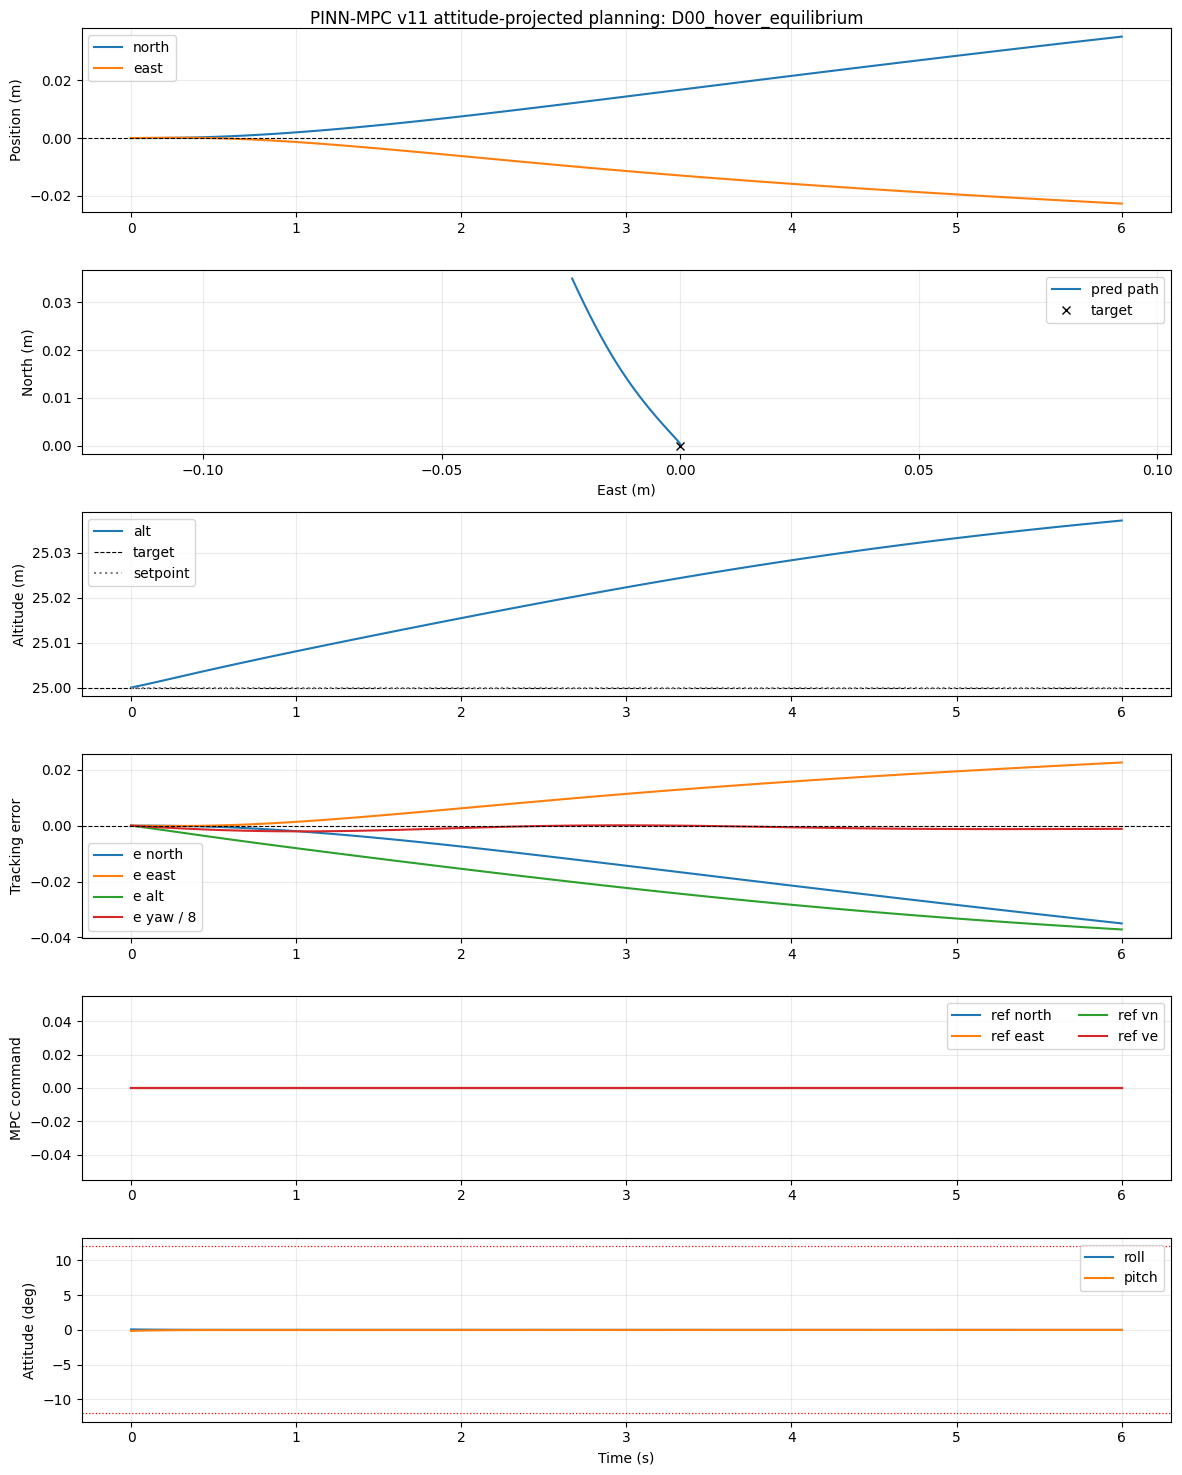

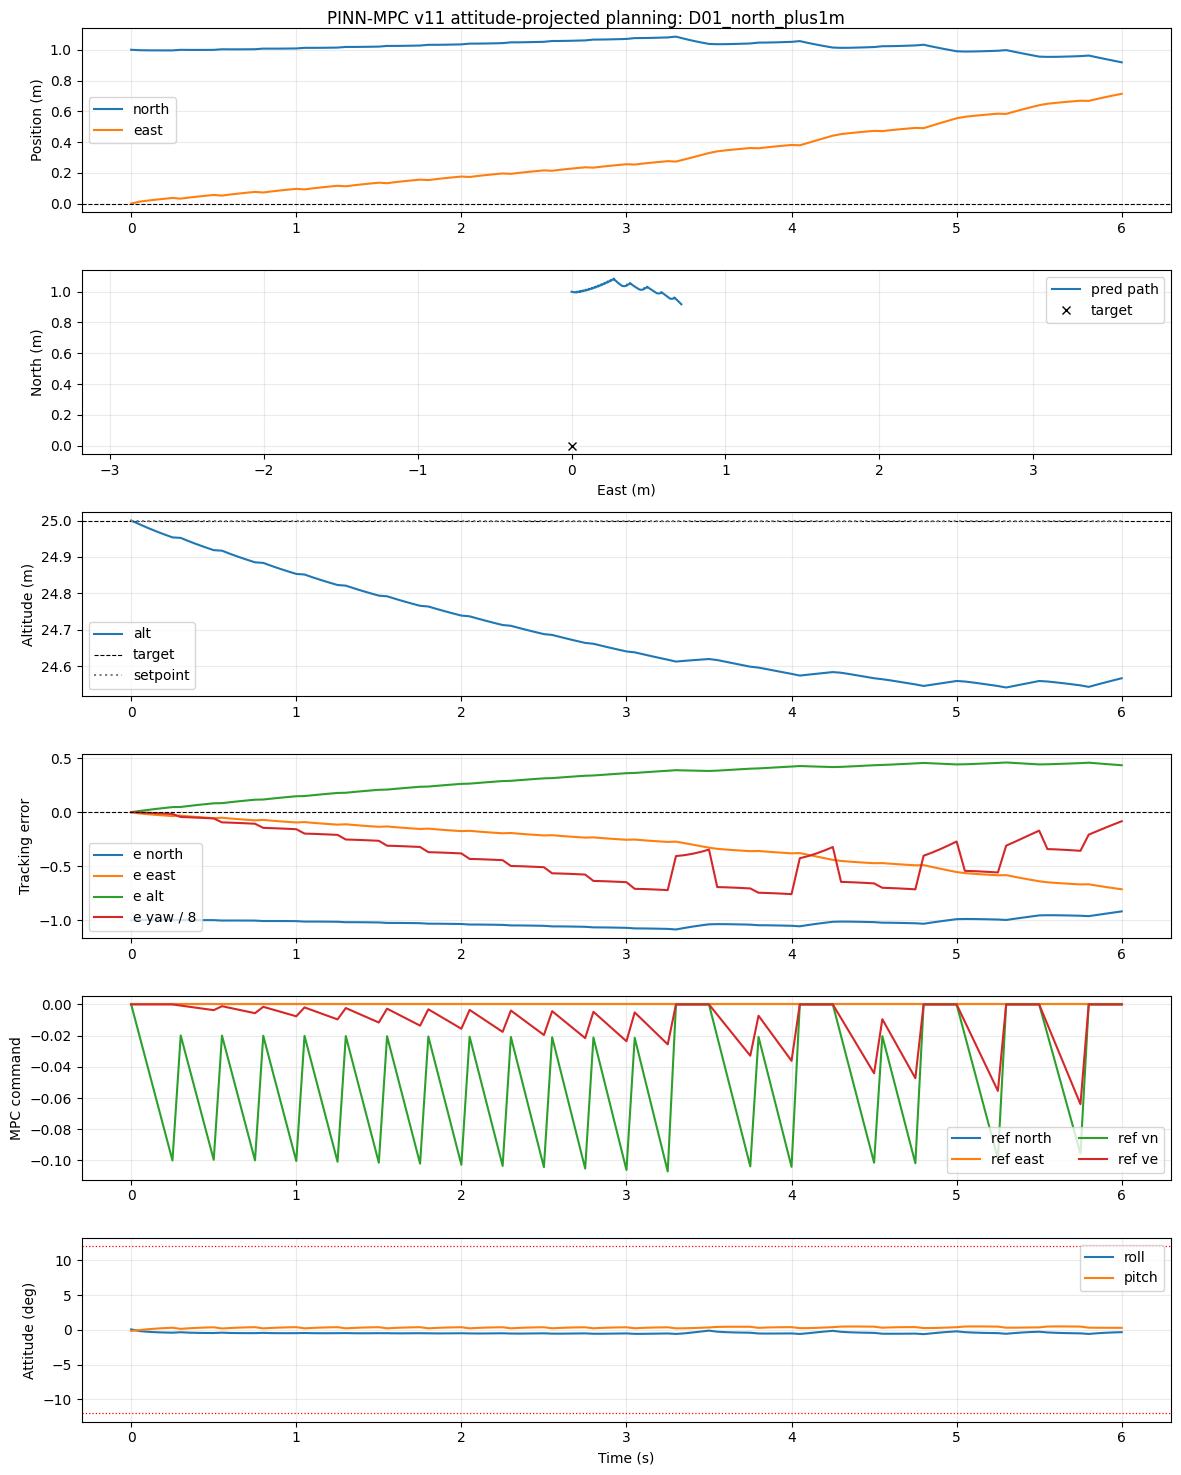

In [15]:
if len(mpc_log):
    def compute_mpc_metrics(log):
        rows = []
        yaw_base = float(HOVER_STATE[state_index['yaw_deg']])
        for case, g in log.groupby('case'):
            pos_err = np.sqrt(g['north_m'] ** 2 + g['east_m'] ** 2)
            alt_err = g['alt_m'] - TARGET_ALT_M
            yaw_err = wrap_deg_np(g['yaw_deg'].to_numpy() - yaw_base)
            speed = np.sqrt(g['vn_m_s'] ** 2 + g['ve_m_s'] ** 2)
            rows.append({
                'case': case,
                'pos_initial_err_m': float(pos_err.iloc[0]),
                'pos_final_err_m': float(pos_err.iloc[-1]),
                'pos_rmse_m': float(np.sqrt(np.mean(pos_err ** 2))),
                'alt_initial_err_m': float(alt_err.iloc[0]),
                'alt_final_err_m': float(alt_err.iloc[-1]),
                'alt_rmse_m': float(np.sqrt(np.mean(alt_err ** 2))),
                'yaw_initial_err_deg': float(yaw_err[0]),
                'yaw_final_err_deg': float(yaw_err[-1]),
                'yaw_rmse_deg': float(np.sqrt(np.mean(yaw_err ** 2))),
                'speed_max_m_s': float(np.max(speed)),
                'max_abs_roll_deg': float(np.max(np.abs(g['roll_deg']))),
                'max_abs_pitch_deg': float(np.max(np.abs(g['pitch_deg']))),
                'recovery_ratio_pos': float(pos_err.iloc[-1] / max(pos_err.iloc[0], 1e-6)),
                'safe_candidate': bool(
                    np.max(np.abs(g['roll_deg'])) < 15.0
                    and np.max(np.abs(g['pitch_deg'])) < 15.0
                    and np.max(speed) < 1.6
                    and abs(alt_err.iloc[-1]) < 0.7
                ),
            })
        return pd.DataFrame(rows)

    mpc_metrics = compute_mpc_metrics(mpc_log)
    display(mpc_metrics)

    for case, g in mpc_log.groupby('case'):
        fig, axes = plt.subplots(6, 1, figsize=(12, 15), sharex=False)
        t = g['time_s']
        fig.suptitle(f'PINN-MPC v11 attitude-projected planning: {case}')
        axes[0].plot(t, g['north_m'], label='north')
        axes[0].plot(t, g['east_m'], label='east')
        axes[0].axhline(0.0, color='k', ls='--', lw=0.8)
        axes[0].set_ylabel('Position (m)')
        axes[0].legend()

        axes[1].plot(g['east_m'], g['north_m'], label='pred path')
        axes[1].plot([0], [0], 'kx', label='target')
        axes[1].set_ylabel('North (m)')
        axes[1].set_xlabel('East (m)')
        axes[1].axis('equal')
        axes[1].legend()

        axes[2].plot(t, g['alt_m'], label='alt')
        axes[2].axhline(TARGET_ALT_M, color='k', ls='--', lw=0.8, label='target')
        axes[2].plot(t, g['ref_alt_m'], '0.5', ls=':', label='setpoint')
        axes[2].set_ylabel('Altitude (m)')
        axes[2].legend()

        axes[3].plot(t, g['e_north_m'], label='e north')
        axes[3].plot(t, g['e_east_m'], label='e east')
        axes[3].plot(t, g['e_alt_m'], label='e alt')
        axes[3].plot(t, g['e_yaw_deg'] / 8.0, label='e yaw / 8')
        axes[3].axhline(0.0, color='k', ls='--', lw=0.8)
        axes[3].set_ylabel('Tracking error')
        axes[3].legend()

        axes[4].plot(t, g['ref_north_m'], label='ref north')
        axes[4].plot(t, g['ref_east_m'], label='ref east')
        axes[4].plot(t, g['ref_vn_m_s'], label='ref vn')
        axes[4].plot(t, g['ref_ve_m_s'], label='ref ve')
        axes[4].set_ylabel('MPC command')
        axes[4].legend(ncol=2)

        axes[5].plot(t, g['roll_deg'], label='roll')
        axes[5].plot(t, g['pitch_deg'], label='pitch')
        axes[5].axhline(12.0, color='r', ls=':', lw=0.9)
        axes[5].axhline(-12.0, color='r', ls=':', lw=0.9)
        axes[5].set_ylabel('Attitude (deg)')
        axes[5].set_xlabel('Time (s)')
        axes[5].legend()
        for ax in axes:
            ax.grid(True, alpha=0.25)
        fig.tight_layout()
        plt.show()
else:
    mpc_metrics = pd.DataFrame()
    print('MPC skipped; hover diagnostics only.')


In [16]:
if Path('/content/drive/MyDrive').exists():
    SAVE_ROOT = Path('/content/drive/MyDrive/Colab Result/PINN_MPC/px4_phase1_closed_loop_pinn_mpc_v14_attitude_projected_planning')
else:
    SAVE_ROOT = Path('/content/px4_phase1_closed_loop_pinn_mpc_v14_attitude_projected_planning')
SAVE_DIR = SAVE_ROOT / time.strftime('%Y%m%d_%H%M%S')
SAVE_DIR.mkdir(parents=True, exist_ok=True)
mpc_log.to_csv(SAVE_DIR / 'pinn_mpc_v14_attitude_projected_planning_log.csv', index=False)
hover_diagnostic_log.to_csv(SAVE_DIR / 'hover_equilibrium_rollout_log.csv', index=False)
hover_diagnostic_metrics.to_csv(SAVE_DIR / 'hover_equilibrium_metrics.csv', index=False)
mpc_metrics.to_csv(SAVE_DIR / 'pinn_mpc_v14_attitude_projected_planning_metrics.csv', index=False)
with open(SAVE_DIR / 'config.json', 'w') as f:
    json.dump({
        'revision': NOTEBOOK_REVISION,
        'best_hover_label': BEST_HOVER_LABEL,
        'checkpoint': str(CKPT_PATH),
        'recovery_cases': RECOVERY_CASES,
        'horizon': MPC_HORIZON,
        'samples': MPC_SAMPLES,
        'elites': MPC_ELITES,
        'iters': MPC_ITERS,
        'control_interval_steps': CONTROL_INTERVAL_STEPS,
        'cost': COST,
        'noise': NOISE,
    }, f, indent=2)
print('saved:', SAVE_DIR)


saved: /content/drive/MyDrive/Colab Result/PINN_MPC/px4_phase1_closed_loop_pinn_mpc_v14_attitude_projected_planning/20260510_063532
